# Proyecto Final del bootcamp de Tripleten: Telecomunicaciones

## Fernando Gutiérrez Canales
### 10.04.2026

#### Primero, llamamos a los datasets

In [21]:
# Importamos las librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
clients = pd.read_csv('Datasets/telecom_clients.csv')
# Mostramos las primeras filas del DataFrame
clients.head()  

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [3]:
dataset = pd.read_csv('Datasets/telecom_dataset_new.csv')
dataset.head()  

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


## Análisis Exploratorio de los Datos
En esta sección realizamos un EDA básico para comprender las variables, valores faltantes, distribuciones y relaciones entre las columnas.

In [4]:
# Resumen general de los datasets
print('Dataset clients:')
print('  filas, columnas =', clients.shape)
print('Dataset dataset:')
print('  filas, columnas =', dataset.shape)

print('\nColumnas de clients:')
print(clients.columns.tolist())
print('\nColumnas de dataset:')
print(dataset.columns.tolist())

print('\nValores faltantes en clients:')
display(clients.isna().sum())
print('\nValores faltantes en dataset:')
display(dataset.isna().sum())

print('\nTipos de datos en clients:')
display(clients.dtypes)
print('\nTipos de datos en dataset:')
display(dataset.dtypes)

Dataset clients:
  filas, columnas = (732, 3)
Dataset dataset:
  filas, columnas = (53902, 9)

Columnas de clients:
['user_id', 'tariff_plan', 'date_start']

Columnas de dataset:
['user_id', 'date', 'direction', 'internal', 'operator_id', 'is_missed_call', 'calls_count', 'call_duration', 'total_call_duration']

Valores faltantes en clients:


user_id        0
tariff_plan    0
date_start     0
dtype: int64


Valores faltantes en dataset:


user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64


Tipos de datos en clients:


user_id         int64
tariff_plan    object
date_start     object
dtype: object


Tipos de datos en dataset:


user_id                  int64
date                    object
direction               object
internal                object
operator_id            float64
is_missed_call            bool
calls_count              int64
call_duration            int64
total_call_duration      int64
dtype: object

Vemos que hay varios datos nulos en los datasets. Vemos además que las columnas 'date' en dataset y 'date_start' en clients son ambos Objetos. Debemos cambiar ambas columnas a fechas. Hagamos eso primero.

In [5]:
# Convertimos la columna 'date_start' en el dataset de clientes
clients['date_start'] = pd.to_datetime(clients['date_start'])

# Convertimos la columna 'date' en el dataset de llamadas. 
dataset['date'] = pd.to_datetime(dataset['date'])


Verificamos que el cambio se haya hecho correctamente

In [6]:
# Verificamos que el cambio se haya aplicado correctamente
print(clients.dtypes)
print(dataset.dtypes)

user_id                 int64
tariff_plan            object
date_start     datetime64[ns]
dtype: object
user_id                                    int64
date                   datetime64[ns, UTC+03:00]
direction                                 object
internal                                  object
operator_id                              float64
is_missed_call                              bool
calls_count                                int64
call_duration                              int64
total_call_duration                        int64
dtype: object


Ahora es momento de ir por los valores nulos en dataset. Este archivo de datos tiene ~53000 datos. De ellos:
- 117 de la columna 'internal' son nulos
- 8172 de la columna 'operator_id' son nulos

Podemos ignorar los nulos de la columna 'internal' pues son muy pocos en comparación con el tamaño del Dataset. Sin embargo, vamos a explorarlos y a decidir después de esto si puedo eliminarlos. 

In [12]:
dataset[dataset['internal'].isna()]

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
1007,166405,2019-09-18 00:00:00+03:00,in,NaN,NaN,True,1,0,59
1090,166405,2019-10-01 00:00:00+03:00,in,NaN,NaN,True,1,0,1
1864,166406,2019-08-20 00:00:00+03:00,in,NaN,NaN,True,1,0,36
1924,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.0,False,1,2,9
6210,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.0,False,1,393,423
...,...,...,...,...,...,...,...,...,...
52462,168361,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,6,0,14
52590,168361,2019-11-13 00:00:00+03:00,in,NaN,NaN,True,2,0,6
52621,168361,2019-11-14 00:00:00+03:00,in,NaN,NaN,True,1,0,2
53717,168579,2019-11-09 00:00:00+03:00,in,NaN,NaN,True,1,0,18


Vemos que los valores nulos parecen ser aleatorios. Así que simplemente los eliminamos con '.dropna()'

In [11]:
dataset_clean_internal = dataset.dropna(subset=['internal']).copy()
dataset_clean_internal['internal'] = dataset_clean_internal['internal'].astype('int64')

Aún más importante que los nulos en 'internal' es resolver el problema de los nulos de la columna 'operator_id'.

In [14]:
# Eliminamos las filas donde 'operator_id' es nulo
dataset_clean = dataset_clean_internal.dropna(subset=['operator_id']).copy()

# Ahora convertimos la columna de float a int, porque tiene más sentido, ya que los IDs son etiquetas
dataset_clean['operator_id'] = dataset_clean['operator_id'].astype('int64')

# Verificamos cuántas filas nos quedaron
print(f"Filas originales: {dataset.shape[0]}")
print(f"Filas después de limpiar nulos en operadores: {dataset_clean.shape[0]}")

Filas originales: 53902
Filas después de limpiar nulos en operadores: 45670


Ahora veamos cómo ha qudado el Dataset limpio

In [8]:
# Aplicamos describe() a nuestro dataset limpio
resumen_estadistico = dataset_clean.describe()

# Lo mostramos en pantalla
display(resumen_estadistico)

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,45730.000000,45730.000000,45730.000000,45730.000000,45730.000000
mean,167302.220315,916535.993002,16.904417,1009.765121,1322.141789
std,600.731240,21254.123136,59.045234,4014.600085,4732.427880
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,68.000000
50%,167175.000000,913938.000000,4.000000,106.000000,290.500000
75%,167827.000000,937708.000000,14.000000,772.000000,1110.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


Ahora vamos a analizar las llamadas perdidas

In [44]:
# Creamos un dataset para analizar las llamadas perdidas
llamadas_perdidas = dataset_clean[dataset_clean['is_missed_call']== True]

# Vemos cuántas llamadas perdidas tenemos por operador
llamadas_perdidas_por_operador = llamadas_perdidas.groupby('operator_id')['is_missed_call'].count().reset_index()

# Creamos la columna
llamadas_perdidas_por_operador.columns = ['operator_id', 'is_missed_call']

# Creamos una columna con el tiempo de espera definido como la diferencia entre la duración total de la llamada y la duración efectiva de la llamada
dataset_clean['wait_time'] = dataset_clean['total_call_duration'] - dataset_clean['call_duration']

Ahora hagamos un histograma con las llamadas perdidas por operador

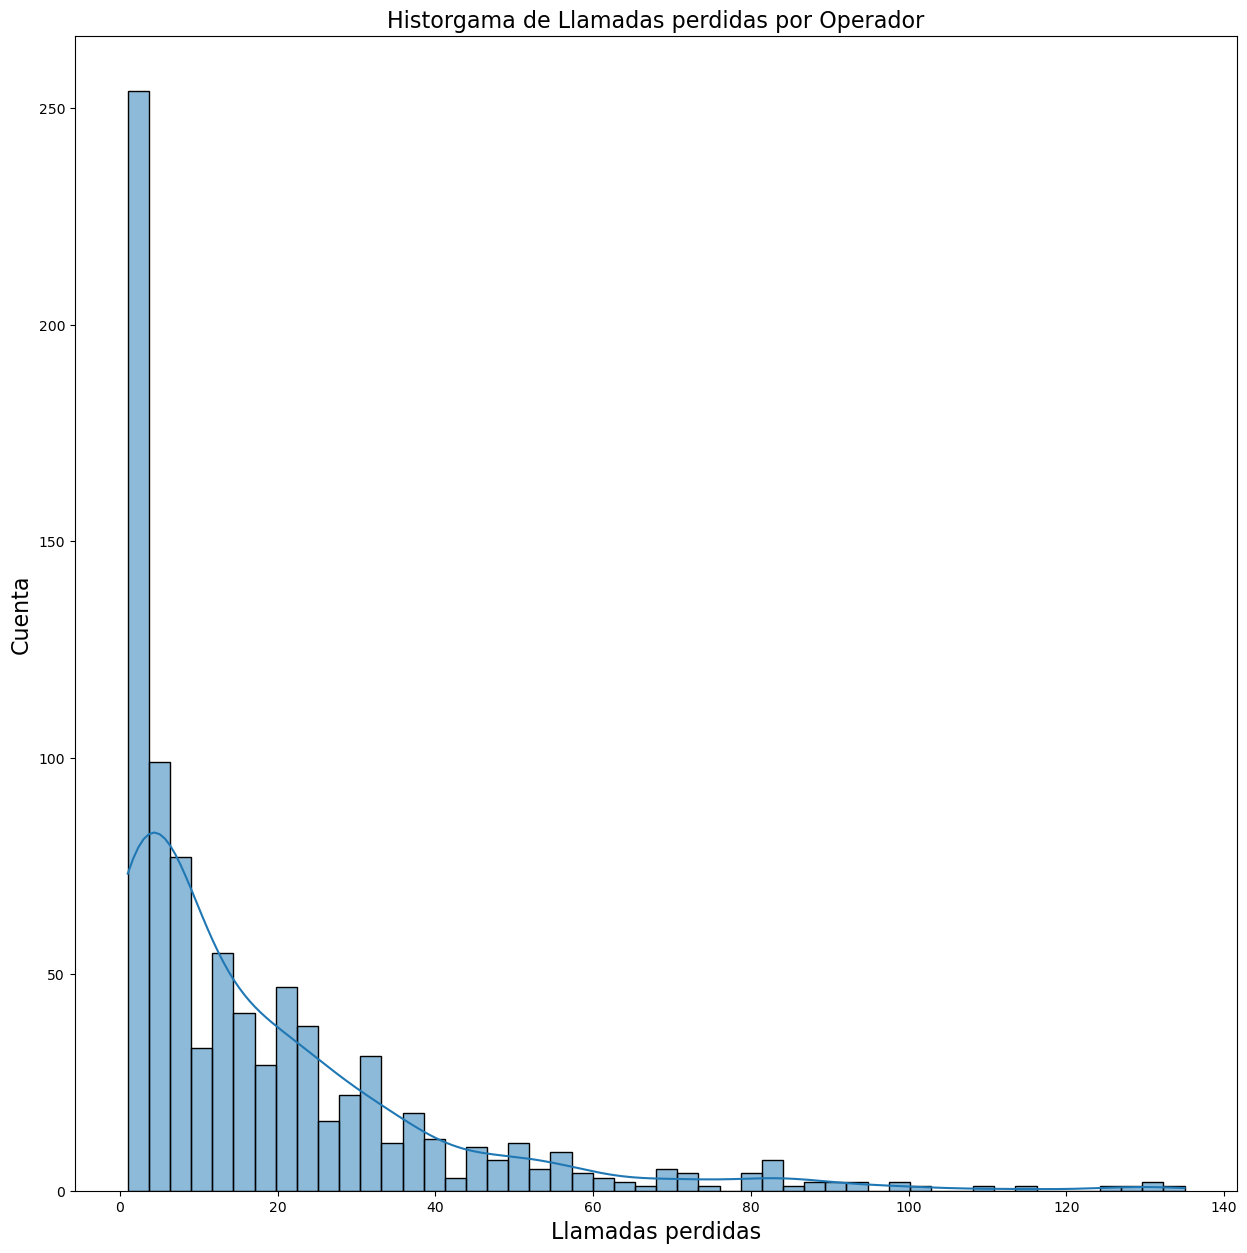

In [34]:
plt.figure(figsize=(15,15))
fsize=16
sns.histplot(data=llamadas_perdidas_por_operador, x='is_missed_call', bins=50, kde=True)
plt.title('Historgama de Llamadas perdidas por Operador', fontsize=fsize)
plt.xlabel('Llamadas perdidas', fontsize=fsize)
plt.ylabel('Cuenta', fontsize=fsize)
plt.show()


Vemos cómo la mayoría de operadores tienen solamente 1 llamada perdida. Ahora haremos un análisis de quartiles para ver, por ejemplo, cuántas llamadas perdidas tiene el 90% de los operadores

In [35]:
umbral_perdidas = llamadas_perdidas_por_operador['is_missed_call'].quantile(0.90)
print(f"El 90% de los operadores tiene {umbral_perdidas} o menos llamadas perdidas.")
print(f"Cualquier operador con más de {umbral_perdidas} llamadas perdidas será considerado ineficaz en este criterio.")

El 90% de los operadores tiene 44.5 o menos llamadas perdidas.
Cualquier operador con más de 44.5 llamadas perdidas será considerado ineficaz en este criterio.


Ahora vamos a saber si los operadores son ineficaces o no. Tenemos que ver si se supone que deberían hacer llamadas de salidas.

In [61]:
# 1. Creamos una tabla cruzada: Operadores en las filas, Dirección ('in'/'out') en las columnas
roles_operadores = pd.crosstab(index=dataset_clean['operator_id'], columns=dataset_clean['direction'])

# El DataFrame resultante tendrá dos columnas llamadas 'in' y 'out' que contienen el conteo de llamadas

# 2. Calculamos el total de llamadas por operador sumando ambas columnas
roles_operadores['total_calls'] = roles_operadores['in'] + roles_operadores['out']

# 3. Calculamos el porcentaje de llamadas salientes (out)
roles_operadores['porcentaje_out'] = (roles_operadores['out'] / roles_operadores['total_calls']) * 100

# 4. Filtramos a los operadores que dedican la mayor parte de su tiempo (ej. > 50%) a llamar
operadores_salientes = roles_operadores[roles_operadores['porcentaje_out'] > 50].copy()

# Guardamos los IDs de estos operadores en una lista para poder filtrar el dataset general más adelante
lista_operadores_salientes = operadores_salientes.index.tolist()

print(f"De un total de {len(roles_operadores)} operadores, se identificaron {len(lista_operadores_salientes)} cuyo rol principal es realizar llamadas salientes.")

De un total de 1092 operadores, se identificaron 750 cuyo rol principal es realizar llamadas salientes.


Ahora el punto es obtener una lista con los operadores ineficaces

In [ ]:
# 1. Creamos una tabla base con todos los operadores únicos
df_ineficacia = dataset_clean[['operator_id']].drop_duplicates().reset_index(drop=True)

# 2. Creamos columnas Booleanas evaluando si el operador está en tus listas de infractores previas

# 1. Creamos una tabla base con todos los operadores únicos
df_ineficacia = dataset_clean[['operator_id']].drop_duplicates().reset_index(drop=True)

# Definimos los grupos de operadores con peor performance en cada dimensión
df_peores_perdidas = llamadas_perdidas_por_operador[
    llamadas_perdidas_por_operador['is_missed_call'] > umbral_perdidas
].copy()

promedio_espera = dataset_clean.groupby('operator_id')['wait_time'].mean().reset_index(name='avg_call_duration')
umbral_espera = promedio_espera['avg_call_duration'].quantile(0.90)
print("El promedio de espera para el 90% de los operadores es de", umbral_espera, "segundos o menos.")

df_peores_esperas = promedio_espera[promedio_espera['avg_call_duration'] > umbral_espera].copy()

operadores_con_rol_saliente = roles_operadores[roles_operadores['porcentaje_out'] > 50].reset_index()
umbral_pocas_salientes = operadores_con_rol_saliente['out'].quantile(0.25)
df_pocas_salientes = operadores_con_rol_saliente[operadores_con_rol_saliente['out'] <= umbral_pocas_salientes].copy()

# 2. Creamos columnas Booleanas evaluando si el operador está en tus listas de infractores previas
df_ineficacia['muchas_perdidas'] = df_ineficacia['operator_id'].isin(df_peores_perdidas['operator_id'])
df_ineficacia['mucho_espera'] = df_ineficacia['operator_id'].isin(df_peores_esperas['operator_id'])

# 3. Agregamos las reglas del rol saliente
df_ineficacia['rol_saliente'] = df_ineficacia['operator_id'].isin(lista_operadores_salientes)
df_ineficacia['pocas_salientes'] = df_ineficacia['operator_id'].isin(df_pocas_salientes['operator_id'])

# 4. APLICAMOS LA FÓRMULA MAESTRA
df_ineficacia['falla_entrantes'] = df_ineficacia['muchas_perdidas'] & df_ineficacia['mucho_espera']
df_ineficacia['falla_salientes'] = df_ineficacia['rol_saliente'] & df_ineficacia['pocas_salientes']
df_ineficacia['es_ineficaz'] = df_ineficacia['falla_entrantes'] | df_ineficacia['falla_salientes']

# 5. Filtramos a los que sí son ineficaces
operadores_castigados = df_ineficacia[df_ineficacia['es_ineficaz'] == True]

print(f"Total de operadores ineficaces encontrados: {len(operadores_castigados)}")
df_ineficacia['mucho_espera'] = df_ineficacia['operator_id'].isin(df_peores_esperas['operator_id'])

# 3. Agregamos las reglas del rol saliente
df_ineficacia['rol_saliente'] = df_ineficacia['operator_id'].isin(lista_operadores_salientes)
df_ineficacia['pocas_salientes'] = df_ineficacia['operator_id'].isin(df_pocas_salientes['operator_id'])

# 4. APLICAMOS LA FÓRMULA MAESTRA

# Ineficacia por llamadas entrantes (Falla la 1 Y la 2)
df_ineficacia['falla_entrantes'] = df_ineficacia['muchas_perdidas'] & df_ineficacia['mucho_espera']

# Ineficacia por llamadas salientes (TIENE el rol Y falla la 3)
df_ineficacia['falla_salientes'] = df_ineficacia['rol_saliente'] & df_ineficacia['pocas_salientes']

# Decisión Final: Falla por un lado O falla por el otro
df_ineficacia['es_ineficaz'] = df_ineficacia['falla_entrantes'] | df_ineficacia['falla_salientes']

# 5. Filtramos a los que sí son ineficaces
operadores_castigados = df_ineficacia[df_ineficacia['es_ineficaz'] == True]

print(f"Total de operadores ineficaces encontrados: {len(operadores_castigados)}")

El promedio de espera para el 90% de los operadores es de 546.6514705882353 segundos o menos.
El umbral de espera para considerar a un operador como ineficaz en este criterio es de 546.6514705882353 segundos o más.
Total de operadores ineficaces encontrados: 205
Total de operadores ineficaces encontrados: 205


## Pruebas de hipótesis

#### Prueba de Hipótesis 1: Impacto del Plan tarifario en la duración de las llamadas

- Hipótesis Nula ($\rm H_{0}$): La duración promedio de las llamadas de los clientes con la tarifa 'A' es IGUAL a la de los clientes con la tarifa 'B' (y 'C').

- Hipótesis Alternativa ($\rm H_{1}$): La duración promedio de las llamadas de los clientes con la tarifa 'A' es DIFERENTE a la de los clientes con la tarifa 'B' (y 'C').

- Métrica a evaluar: call_duration.

- Nivel de significancia ($\alpha$): 0.05

In [46]:
from scipy import stats

# 1. Unimos el dataset limpio con la tabla de clientes usando la columna en común 'user_id'
# Usamos un 'left' join para no perder llamadas, agregando el plan a cada registro
df_completo = dataset_clean.merge(clients[['user_id', 'tariff_plan']], on='user_id', how='left')

# 2. Filtramos los dos grupos que queremos comparar
# Ojo: Asegúrate de ver cómo están escritos los planes en tu dataset (ej. 'A', 'B', 'C')
grupo_plan_A = df_completo[df_completo['tariff_plan'] == 'A']['call_duration']
grupo_plan_B = df_completo[df_completo['tariff_plan'] == 'B']['call_duration']

# 3. Configuramos el nivel de significancia (alfa)
alpha = 0.05

# 4. Aplicamos la Prueba T de Student para muestras independientes
# equal_var=False aplica la prueba de Welch, recomendada cuando los grupos tienen tamaños diferentes
results = stats.ttest_ind(grupo_plan_A, grupo_plan_B, equal_var=False)

print(f"Valor p: {results.pvalue}")

# 5. Lógica de conclusión
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Hay una diferencia estadísticamente significativa en la duración de las llamadas entre los planes.")
else:
    print("No podemos rechazar la hipótesis nula: No hay evidencia suficiente para decir que los planes afectan la duración de la llamada.")

Valor p: 5.5295114068498496e-62
Rechazamos la hipótesis nula: Hay una diferencia estadísticamente significativa en la duración de las llamadas entre los planes.


### Conclusión de la primer prueba de hipótesis:
Las llamadas hechas por clientes de distintos planes suelen tener distintas duraciones dadas las diferentes necesidades y perfiles de los clientes.

#### Prueba de Hipótesis 2: Tiempo de espera en llamadas
- Hipótesis nula ($\rm H_{0}$): La duración del tiempo de espera es EL MISMO para las llamadas internas y las llamadas externas.
- Hiótesis alternativa ($\rm H_{1}$): La duración del tiempo de espera es DISTINTO para las llamadas internas y las llamadas externas.
- Métrica a evaluar: 'wait_time'
- Nivel de significancia ($\alpha$): 0.05

In [54]:
# Primero, creamos dos grupos: uno para llamadas internas y otro para llamadas externas
grupo_internas = dataset_clean[dataset_clean['internal']==1]
grupo_externas = dataset_clean[dataset_clean['internal']==0]

# Ahora extraemos la duración del tiempo de espera, 'wait_time', para cada grupo
espera_internas = grupo_internas['wait_time']
espera_externas = grupo_externas['wait_time']

# Aplicamos la prueba T de Student para comparar la duración de las llamadas entre internas y externas
alpha = 0.05
results_espera = stats.ttest_ind(espera_internas, espera_externas, equal_var=False)

print("El valor de p es:", results_espera.pvalue)

# Imprimimos el resultado
if results_espera.pvalue < alpha:
    print("Rechazamos la hipótesis nula: El tiempo de espera es significativamente distinto entre llamadas externas e internas")
else:
    print("No podemos rechazar la hipótesis nula: El tiempo de espera es igual entre llamadas externas e internas")


El valor de p es: 0.0
Rechazamos la hipótesis nula: El tiempo de espera es significativamente distinto entre llamadas externas e internas


### Conclusión de la segunda prueba de hipótesis:
Los tiempos de espera entre las llamadas internas (entre los trabajadores del Call Center) y las externas (entre trabajadores y clientes) desde lueggo que serán diferentes dada la diferente naturaleza de los motivos de las llamadas.

#### Prueba de Hipótesis 3: Volumen de llamadas
- Hipótesis nula ($\rm H_{0}$): La duración del tiempo de espera es EL MISMO para las llamadas internas y las llamadas externas.
- Hiótesis alternativa ($\rm H_{1}$): La duración del tiempo de espera es DISTINTO para las llamadas internas y las llamadas externas.
- Métrica a evaluar: 'wait_time'
- Nivel de significancia ($\alpha$): 0.05

In [ ]:
# Agrupamos por operador y sumamos la columna 'calls_count'
volumen_por_operador = dataset_clean.groupby('operator_id')['calls_count'].sum().reset_index()

# Extraemos la lista de los IDs de tus 212 operadores ineficaces 
lista_ineficaces = operadores_castigados['operator_id'].tolist()

# 2. Separamos a la empresa en dos grupos usando el símbolo '~' (que significa NOT en Pandas)
grupo_ineficaces = volumen_por_operador[volumen_por_operador['operator_id'].isin(lista_ineficaces)]['calls_count']
grupo_eficaces = volumen_por_operador[~volumen_por_operador['operator_id'].isin(lista_ineficaces)]['calls_count']

# 3. Definimos nuestro nivel de significancia
alpha = 0.05

# 4. Aplicamos la Prueba T de Student
results_volumen = stats.ttest_ind(grupo_ineficaces, grupo_eficaces, equal_var=False)

print(f"\nValor p de la Prueba T: {results_volumen.pvalue}")

# 5. Conclusión estadística
if results_volumen.pvalue < alpha:
    print("Rechazamos la hipótesis nula: Existe una diferencia estadísticamente significativa en el volumen de llamadas entre operadores ineficaces y eficaces.")
else:
    print("No podemos rechazar la hipótesis nula: El volumen de llamadas es similar entre ambos grupos.")


Valor p de la Prueba T: 0.9378326149608432
No podemos rechazar la hipótesis nula: El volumen de llamadas es similar entre ambos grupos.


### Conclusión de la tercer prueba de hipótesis

El volumen de llamadas es básicamente el mismo para ambos operadores, los ineficaces y los eficaces. Esto muestra un problema: Si los operadores ineficaces solamente manejaran un volumen pequeño, no generarían pérdidas significativas para el Call Center. Pero no es el caso.

In [57]:
path = 'Datasets/'

# 1. Exportamos el dataset principal limpio (ideal para tus histogramas y gráficos circulares en Tableau)
dataset_clean.to_csv(path + 'llamadas_limpias.csv', index=False)

# 2. Exportamos tu lista de ineficaces (para que en Tableau puedas poner un filtro de "Es Ineficaz: Sí/No")
operadores_castigados.to_csv(path + 'operadores_ineficaces.csv', index=False)

# 3. Exportamos tu tabla unida con clientes (por si quieres graficar cosas por plan tarifario)
df_completo.to_csv(path + 'llamadas_con_planes.csv', index=False)

print("¡Archivos CSV exportados con éxito! Listos para Tableau.")

¡Archivos CSV exportados con éxito! Listos para Tableau.
